# Домашнее задание №2: EDA — Spotify Tracks Dataset

**Датасет:** [Spotify Tracks Dataset — Audio Features](https://www.kaggle.com/datasets/saichaitanyareddyai/spotify-tracks-dataset-audio-features)

Датасет содержит информацию о музыкальных треках с платформы Spotify:
- 🎼 Аудиохарактеристики: `energy`, `danceability`, `tempo`, `loudness`, `acousticness` и др.
- 📊 Популярность трека (`popularity`)
- 🎸 Жанр (`track_genre`) и исполнитель (`artists`)

**Содержание ноутбука:**
1. Импорт библиотек и загрузка данных
2. A) Быстрый обзор данных
3. B) Пропуски и очистка
4. C) Расширенная статистика
5. D) Feature Engineering и Энкодинг
6. E) Визуализация
7. F) Итоговые выводы и гипотезы


## ⚙️ Установка зависимостей и импорт библиотек

In [2]:
!pip -q install category_encoders
from category_encoders import HashingEncoder

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 85.9/85.9 kB 2.3 MB/s eta 0:00:00


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import category_encoders as ce
from sklearn.preprocessing import LabelEncoder

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 12
pd.set_option('display.max_columns', None)
sns.set_theme(font_scale=1.2)

In [4]:
import kagglehub, os

path = kagglehub.dataset_download(
    'saichaitanyareddyai/spotify-tracks-dataset-audio-features'
)
csv_files = [f for f in os.listdir(path) if f.lower().endswith('.csv')]
if not csv_files:
    raise FileNotFoundError('CSV-файл не найден!')

df = pd.read_csv(os.path.join(path, csv_files[0]))
print(f'Датасет загружен: {df.shape[0]:,} строк, {df.shape[1]} колонок')

100%|██████████| 7.90M/7.90M [00:00<00:00, 135MB/s]

Extracting files...


Датасет загружен: 114,000 строк, 20 колонок


## A) Быстрый обзор данных (Pandas)


In [5]:
print('Первые 5 строк:')
df.head()

Первые 5 строк:


,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,73,230666,False,0.676,0.4610,1,-6.746,0,0.1430,0.0322,0.000001,0.3580,0.715,87.917,4,acoustic
1,4qPNDBW1i3p13qLCt0Ki3A,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55,149610,False,0.420,0.1660,1,-17.235,1,0.0763,0.9240,0.000006,0.1010,0.267,77.489,4,acoustic
2,1iJBSr7s7jYXzM8EGcbK5b,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,57,210826,False,0.438,0.3590,0,-9.734,1,0.0557,0.2100,0.000000,0.1170,0.120,76.332,4,acoustic
3,6lfxq3CG4xtTiEg7opyCyx,Kina Grannis,Crazy Rich Asians (Original Motion Picture Sou...,Can't Help Falling In Love,71,201933,False,0.266,0.0596,0,-18.515,1,0.0363,0.9050,0.000071,0.1320,0.143,181.740,3,acoustic
4,5vjLSffimiIP26QG5WcN2K,Chord Overstreet,Hold On,Hold On,82,198853,False,0.618,0.4430,2,-9.681,1,0.0526,0.4690,0.000000,0.0829,0.167,119.949,4,acoustic


In [6]:
print('Последние 5 строк:')
df.tail()

Последние 5 строк:


,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
113995,2C3TZjDRiAzdyViavDJ217,Rainy Lullaby,#mindfulness - Soft Rain for Mindful Meditatio...,Sleep My Little Boy,21,384999,False,0.172,0.235,5,-16.393,1,0.0422,0.640,0.928,0.0863,0.0339,125.995,5,world-music
113996,1hIz5L4IB9hN3WRYPOCGPw,Rainy Lullaby,#mindfulness - Soft Rain for Mindful Meditatio...,Water Into Light,22,385000,False,0.174,0.117,0,-18.318,0,0.0401,0.994,0.976,0.1050,0.0350,85.239,4,world-music
113997,6x8ZfSoqDjuNa5SVP5QjvX,Cesária Evora,Best Of,Miss Perfumado,22,271466,False,0.629,0.329,0,-10.895,0,0.0420,0.867,0.000,0.0839,0.7430,132.378,4,world-music
113998,2e6sXL2bYv4bSz6VTdnfLs,Michael W. Smith,Change Your World,Friends,41,283893,False,0.587,0.506,7,-10.889,1,0.0297,0.381,0.000,0.2700,0.4130,135.960,4,world-music
113999,2hETkH7cOfqmz3LqZDHZf5,Cesária Evora,Miss Perfumado,Barbincor,22,241826,False,0.526,0.487,1,-10.204,0,0.0725,0.681,0.000,0.0893,0.7080,79.198,4,world-music


In [7]:
print(f'Форма датасета: {df.shape[0]:,} строк x {df.shape[1]} колонок')

Форма датасета: 114,000 строк x 20 колонок


In [8]:
print('Общая информация о датафрейме:')
df.info()

Общая информация о датафрейме:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 114000 entries, 0 to 113999
Data columns (total 20 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   track_id          114000 non-null  object 
 1   artists           113999 non-null  object 
 2   album_name        113999 non-null  object 
 3   track_name        113999 non-null  object 
 4   popularity        114000 non-null  int64  
 5   duration_ms       114000 non-null  int64  
 6   explicit          114000 non-null  bool   
 7   danceability      114000 non-null  float64
 8   energy            114000 non-null  float64
 9   key               114000 non-null  int64  
 10  loudness          114000 non-null  float64
 11  mode              114000 non-null  int64  
 12  speechiness       114000 non-null  float64
 13  acousticness      114000 non-null  float64
 14  instrumentalness  114000 non-null  float64
 15  liveness          114000 non-null  fl

In [10]:
print('Числовая статистика:')
df.describe()

Числовая статистика:


,popularity,duration_ms,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature
count,114000.000000,1.140000e+05,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000
mean,33.238535,2.280292e+05,0.566800,0.641383,5.309140,-8.258960,0.637553,0.084652,0.314910,0.156050,0.213553,0.474068,122.147837,3.904035
std,22.305078,1.072977e+05,0.173542,0.251529,3.559987,5.029337,0.480709,0.105732,0.332523,0.309555,0.190378,0.259261,29.978197,0.432621
min,0.000000,0.000000e+00,0.000000,0.000000,0.000000,-49.531000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,17.000000,1.740660e+05,0.456000,0.472000,2.000000,-10.013000,0.000000,0.035900,0.016900,0.000000,0.098000,0.260000,99.218750,4.000000
50%,35.000000,2.129060e+05,0.580000,0.685000,5.000000,-7.004000,1.000000,0.048900,0.169000,0.000042,0.132000,0.464000,122.017000,4.000000
75%,50.000000,2.615060e+05,0.695000,0.854000,8.000000,-5.003000,1.000000,0.084500,0.598000,0.049000,0.273000,0.683000,140.071000,4.000000
max,100.000000,5.237295e+06,0.985000,1.000000,11.000000,4.532000,1.000000,0.965000,0.996000,1.000000,1.000000,0.995000,243.372000,5.000000


In [11]:
print('Статистика категориальных колонок:')
df.describe(include='object')

Статистика категориальных колонок:


,track_id,artists,album_name,track_name,track_genre
count,114000,113999,113999,113999,114000
unique,89741,31437,46589,73608,114
top,6S3JlDAGk3uu3NtZbPnuhS,The Beatles,Alternative Christmas 2022,Run Rudolph Run,acoustic
freq,9,279,195,151,1000


In [12]:
print('Пропущенные значения:')
missing = df.isnull().sum()
missing[missing > 0].rename('кол-во пропусков').to_frame()

Пропущенные значения:


,кол-во пропусков
artists,1
album_name,1
track_name,1


In [13]:
dup_count = df.duplicated().sum()
print(f'Дублирующихся строк: {dup_count}')

Дублирующихся строк: 450


In [14]:
print('Типы данных:')
df.dtypes.rename('dtype').to_frame()

Типы данных:


,dtype
track_id,object
artists,object
album_name,object
track_name,object
popularity,int64
duration_ms,int64
explicit,bool
danceability,float64
energy,float64
key,int64


## B) Пропуски и очистка данных


### Стратегии заполнения пропусков

| Стратегия | Когда применять | Пример |
|-----------|----------------|--------|
| **Среднее** (`mean`) | Числовые признаки с симметричным распределением, без выбросов | `tempo` |
| **Медиана** (`median`) | Числовые признаки с асимметрией или выбросами (устойчива к ним) | `popularity` |
| **Константа** (`fillna(value)`) | Когда пропуск имеет смысловое значение (например, «не указано») | `explicit = False` |
| **Мода** (`mode`) | Категориальные признаки | `artists` |


In [15]:
print('Состояние пропусков ДО обработки:')
print(df.isnull().sum())

Состояние пропусков ДО обработки:
track_id            0
artists             1
album_name          1
track_name          1
popularity          0
duration_ms         0
explicit            0
danceability        0
energy              0
key                 0
loudness            0
mode                0
speechiness         0
acousticness        0
instrumentalness    0
liveness            0
valence             0
tempo               0
time_signature      0
track_genre         0
dtype: int64


In [16]:
# Стратегия 1: заполнение СРЕДНИМ
# Среднее хорошо работает, когда нет сильных выбросов.
df['tempo'] = df['tempo'].fillna(df['tempo'].mean())
print(f'tempo: пропусков после заполнения средним: {df["tempo"].isnull().sum()}')

tempo: пропусков после заполнения средним: 0


In [17]:
# Стратегия 2: заполнение МЕДИАНОЙ
# Медиана устойчива к выбросам и лучше отражает 'типичное' значение.
df['popularity'] = df['popularity'].fillna(df['popularity'].median())
print(f'popularity: пропусков после заполнения медианой: {df["popularity"].isnull().sum()}')

popularity: пропусков после заполнения медианой: 0


In [18]:
# Стратегия 3: заполнение КОНСТАНТОЙ
# Для булевых или бинарных признаков пропуск обычно означает 'нет'.
if 'explicit' in df.columns:
    df['explicit'] = df['explicit'].fillna(False)
    print(f'explicit: пропусков после заполнения константой: {df["explicit"].isnull().sum()}')
else:
    print('Колонка explicit отсутствует в датасете')

explicit: пропусков после заполнения константой: 0


In [19]:
#Стратегия 4: заполнение МОДОЙ (категориальные признаки)
# Для строковых/категориальных колонок нельзя вычислить среднее.
# Мода — наиболее часто встречающееся значение
moda_art = df['artists'].mode()[0]  # [0] — берём первое значение моды
print(f'Мода artists: {moda_art!r}')
df['artists'] = df['artists'].fillna(moda_art)
print(f'artists: пропусков после заполнения модой: {df["artists"].isnull().sum()}')

Мода artists: 'The Beatles'
artists: пропусков после заполнения модой: 0


In [20]:
print('Состояние пропусков ПОСЛЕ обработки:')
df.isnull().sum()

Состояние пропусков ПОСЛЕ обработки:


,0
track_id,0
artists,0
album_name,1
track_name,1
popularity,0
duration_ms,0
explicit,0
danceability,0
energy,0
key,0


## C) Расширенная статистика


In [21]:
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns
print(f'Числовые колонки: {list(numeric_cols)}')

Числовые колонки: ['popularity', 'duration_ms', 'danceability', 'energy', 'key', 'loudness', 'mode', 'speechiness', 'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo', 'time_signature']


In [23]:
#Базовые статистики по всем числовым колонкам
stats = pd.DataFrame({
    'min':    df[numeric_cols].min(),
    'max':    df[numeric_cols].max(),
    'mean':   df[numeric_cols].mean().round(3),
    'median': df[numeric_cols].median(),
    'mode':   df[numeric_cols].mode().iloc[0],
})
stats.T

,popularity,duration_ms,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature
min,0.000,0.000,0.000,0.000,0.000,-49.531,0.000,0.0000,0.000,0.000000,0.000,0.000,0.000,0.000
max,100.000,5237295.000,0.985,1.000,11.000,4.532,1.000,0.9650,0.996,1.000000,1.000,0.995,243.372,5.000
mean,33.239,228029.153,0.567,0.641,5.309,-8.259,0.638,0.0850,0.315,0.156000,0.214,0.474,122.148,3.904
median,35.000,212906.000,0.580,0.685,5.000,-7.004,1.000,0.0489,0.169,0.000042,0.132,0.464,122.017,4.000
mode,0.000,162897.000,0.647,0.876,7.000,-5.662,1.000,0.0323,0.995,0.000000,0.108,0.961,0.000,4.000


In [25]:
#Перцентили: 5, 25, 50, 75, 95
quantiles = df[numeric_cols].quantile([0.05, 0.25, 0.50, 0.75, 0.95])
quantiles.index = ['5%', '25%', '50%', '75%', '95%']
print('Перцентили:')
quantiles.T

Перцентили:


,5%,25%,50%,75%,95%
popularity,0.000000,17.00000,35.000000,50.0000,69.00000
duration_ms,116920.000000,174066.00000,212906.000000,261506.0000,387167.10000
danceability,0.250000,0.45600,0.580000,0.6950,0.82400
energy,0.154000,0.47200,0.685000,0.8540,0.96900
key,0.000000,2.00000,5.000000,8.0000,11.00000
loudness,-18.067000,-10.01300,-7.004000,-5.0030,-2.97400
mode,0.000000,0.00000,1.000000,1.0000,1.00000
speechiness,0.028200,0.03590,0.048900,0.0845,0.26800
acousticness,0.000145,0.01690,0.169000,0.5980,0.94800
instrumentalness,0.000000,0.00000,0.000042,0.0490,0.90400


In [27]:
#Дисперсия, асимметрия, эксцесс
adv_stats = pd.DataFrame({
    'variance': df[numeric_cols].var().round(2),
    'skewness': df[numeric_cols].skew().round(3),
    'kurtosis': df[numeric_cols].kurtosis().round(3),
})
print('Дисперсия, асимметрия, эксцесс:')
adv_stats

Дисперсия, асимметрия, эксцесс:


,variance,skewness,kurtosis
popularity,4.975200e+02,0.046,-0.928
duration_ms,1.151280e+10,11.195,354.952
danceability,3.000000e-02,-0.399,-0.185
energy,6.000000e-02,-0.597,-0.526
key,1.267000e+01,-0.009,-1.277
loudness,2.529000e+01,-2.007,5.896
mode,2.300000e-01,-0.572,-1.673
speechiness,1.000000e-02,4.648,28.824
acousticness,1.100000e-01,0.727,-0.950
instrumentalness,1.000000e-01,1.734,1.271


### Интерпретация дисперсии, асимметрии и эксцесса

**Дисперсия (Variance)** — измеряет разброс значений вокруг среднего.
- У `duration_ms` огромная дисперсия — треки сильно различаются по длительности.
- У `danceability`, `energy`, `valence` дисперсия умеренная (диапазон 0–1) — хорошая вариативность.

**Асимметрия (Skewness)** — показывает, в какую сторону смещён «хвост» распределения.
- `skewness > 0` (правый хвост): `popularity` — большинство треков средней популярности, но есть редкие суперхиты.
- `skewness < 0` (левый хвост): `loudness` — большинство треков достаточно громкие, тихих мало.
- Значения близко к 0 (`energy`, `tempo`) — распределения близки к симметричным.

**Эксцесс (Kurtosis)** — описывает «остроту» пика и «тяжесть» хвостов (норма = 0).
- `kurtosis > 0` (лептокуртик): высокий у `popularity` — есть «толстые хвосты», т.е. выбросы. Видно на boxplot.
- `kurtosis < 0` (платикуртик): у `danceability` — плоское, равномерное распределение без острого пика.


## D) Feature Engineering и Энкодинг категорий


### Генерация новых признаков

In [28]:
# Новый признак 1: длительность в минутах
df['duration_min'] = df['duration_ms'] / 60000
print('duration_min (первые значения):')
df[['duration_ms', 'duration_min']].head()

duration_min (первые значения):


,duration_ms,duration_min
0,230666,3.844433
1,149610,2.493500
2,210826,3.513767
3,201933,3.365550
4,198853,3.314217


In [29]:
# Новый признак 2: 'энергия танцевальности' — произведение energy и danceability.
# Треки с высоким значением обоих признаков теоретически наиболее подходят для танцев.
df['energy_dance'] = df['energy'] * df['danceability']
print('Топ-5 треков по energy_dance:')
df.nlargest(5, 'energy_dance')[['track_name', 'energy', 'danceability', 'energy_dance']]

Топ-5 треков по energy_dance:


,track_name,energy,danceability,energy_dance
13168,Most Wanted,0.980,0.976,0.956480
37738,TIPO HARIEL - SEI QUE E RARIDADE -,0.987,0.951,0.938637
37598,AUTOMOTIVO DA FELICIDADE,0.984,0.940,0.924960
13254,The Music In Me - Original Mix,0.952,0.970,0.923440
66293,Hiphop-O-Potamus - Feat. Jabari & Baby Power,0.969,0.947,0.917643


In [30]:
# Новый признак 3: редкие исполнители -> группа 'Other'
# Признаки с сотнями уникальных значений создают проблемы при One-Hot Encoding.
# Объединяем исполнителей, встречающихся менее 2 раз, в категорию 'Other'.
vc = df['artists'].value_counts()
rare = vc[vc < 2].index
df['artists_grouped'] = df['artists'].replace(rare, 'Other')
print(f'Уникальных artists: {df["artists"].nunique()}, после группировки: {df["artists_grouped"].nunique()}')

print('\nДатафрейм с новыми признаками:')
df[['duration_ms', 'duration_min', 'energy', 'danceability', 'energy_dance',
    'artists', 'artists_grouped']].head()

Уникальных artists: 31437, после группировки: 14671

Датафрейм с новыми признаками:


,duration_ms,duration_min,energy,danceability,energy_dance,artists,artists_grouped
0,230666,3.844433,0.4610,0.676,0.311636,Gen Hoshino,Gen Hoshino
1,149610,2.493500,0.1660,0.420,0.069720,Ben Woodward,Ben Woodward
2,210826,3.513767,0.3590,0.438,0.157242,Ingrid Michaelson;ZAYN,Other
3,201933,3.365550,0.0596,0.266,0.015854,Kina Grannis,Kina Grannis
4,198853,3.314217,0.4430,0.618,0.273774,Chord Overstreet,Chord Overstreet


### Кодирование категорий

#### 1. One-Hot Encoding (`pd.get_dummies`)
Каждый уникальный жанр превращается в отдельную бинарную колонку (1/0).
**Подходит**: когда категорий немного и они не имеют порядка.


In [31]:
print('ДО One-Hot Encoding:')
print(df[['track_genre']].head())

df_ohe = pd.get_dummies(df[['track_genre']], columns=['track_genre'], drop_first=False)
print(f'\nПОСЛЕ One-Hot Encoding: {df_ohe.shape[1]} колонок')
df_ohe.head()

ДО One-Hot Encoding:
  track_genre
0    acoustic
1    acoustic
2    acoustic
3    acoustic
4    acoustic

ПОСЛЕ One-Hot Encoding: 114 колонок


,track_genre_acoustic,track_genre_afrobeat,track_genre_alt-rock,track_genre_alternative,track_genre_ambient,track_genre_anime,track_genre_black-metal,track_genre_bluegrass,track_genre_blues,track_genre_brazil,track_genre_breakbeat,track_genre_british,track_genre_cantopop,track_genre_chicago-house,track_genre_children,track_genre_chill,track_genre_classical,track_genre_club,track_genre_comedy,track_genre_country,track_genre_dance,track_genre_dancehall,track_genre_death-metal,track_genre_deep-house,track_genre_detroit-techno,track_genre_disco,track_genre_disney,track_genre_drum-and-bass,track_genre_dub,track_genre_dubstep,track_genre_edm,track_genre_electro,track_genre_electronic,track_genre_emo,track_genre_folk,track_genre_forro,track_genre_french,track_genre_funk,track_genre_garage,track_genre_german,track_genre_gospel,track_genre_goth,track_genre_grindcore,track_genre_groove,track_genre_grunge,track_genre_guitar,track_genre_happy,track_genre_hard-rock,track_genre_hardcore,track_genre_hardstyle,track_genre_heavy-metal,track_genre_hip-hop,track_genre_honky-tonk,track_genre_house,track_genre_idm,track_genre_indian,track_genre_indie,track_genre_indie-pop,track_genre_industrial,track_genre_iranian,track_genre_j-dance,track_genre_j-idol,track_genre_j-pop,track_genre_j-rock,track_genre_jazz,track_genre_k-pop,track_genre_kids,track_genre_latin,track_genre_latino,track_genre_malay,track_genre_mandopop,track_genre_metal,track_genre_metalcore,track_genre_minimal-techno,track_genre_mpb,track_genre_new-age,track_genre_opera,track_genre_pagode,track_genre_party,track_genre_piano,track_genre_pop,track_genre_pop-film,track_genre_power-pop,track_genre_progressive-house,track_genre_psych-rock,track_genre_punk,track_genre_punk-rock,track_genre_r-n-b,track_genre_reggae,track_genre_reggaeton,track_genre_rock,track_genre_rock-n-roll,track_genre_rockabilly,track_genre_romance,track_genre_sad,track_genre_salsa,track_genre_samba,track_genre_sertanejo,track_genre_show-tunes,track_genre_singer-songwriter,track_genre_ska,track_genre_sleep,track_genre_songwriter,track_genre_soul,track_genre_spanish,track_genre_study,track_genre_swedish,track_genre_synth-pop,track_genre_tango,track_genre_techno,track_genre_trance,track_genre_trip-hop,track_genre_turkish,track_genre_world-music
0,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
1,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
2,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,Fals

#### 2. Label Encoding
Каждой категории присваивается уникальное целое число.
**Подходит**: для деревьев решений или когда память ограничена. Вводит ложный порядковый смысл между категориями.


In [ ]:
le = LabelEncoder()
df['genre_label'] = le.fit_transform(df['track_genre'])

print('Пример Label Encoding:')
df[['track_genre', 'genre_label']].drop_duplicates().sort_values('genre_label').head(10)

#### 3. Target Encoding
Каждая категория заменяется средним значением целевой переменной (`popularity`) внутри этой группы.
**Подходит**: для предсказательного моделирования, особенно когда категорий много.


In [32]:
print('ДО Target Encoding:')
print(df[['track_genre', 'popularity']].head())

target_enc = df.groupby('track_genre')['popularity'].mean()
df['genre_target_enc'] = df['track_genre'].map(target_enc)

print('\nПОСЛЕ Target Encoding (жанры по средней популярности):')
df[['track_genre', 'genre_target_enc']].drop_duplicates()\
    .sort_values('genre_target_enc', ascending=False).head(10)

ДО Target Encoding:
  track_genre  popularity
0    acoustic          73
1    acoustic          55
2    acoustic          57
3    acoustic          71
4    acoustic          82

ПОСЛЕ Target Encoding (жанры по средней популярности):


,track_genre,genre_target_enc
80000,pop-film,59.283
65000,k-pop,56.896
15000,chill,53.651
94000,sad,52.379
44000,grunge,49.594
55000,indian,49.539
5000,anime,48.772
33000,emo,48.128
97000,sertanejo,47.866
81000,pop,47.576


#### 4. Feature Hashing (HashingEncoder)
Применяет хеш-функцию к категории и распределяет её в фиксированное число колонок.
**Подходит**: когда категорий очень много (сотни/тысячи уникальных исполнителей) — OHE создал бы матрицу с сотнями колонок, что замедляет обучение.


In [33]:
hash_encoder = ce.HashingEncoder(cols=['artists'], n_components=8)
df_hash = hash_encoder.fit_transform(df[['artists']])

print(f'Исходная колонка artists -> {df_hash.shape[1]} хеш-колонок')
df_hash.head()

Исходная колонка artists -> 8 хеш-колонок


,col_0,col_1,col_2,col_3,col_4,col_5,col_6,col_7
0,0,0,0,1,0,0,0,0
1,1,0,0,0,0,0,0,0
2,0,0,1,0,0,0,0,0
3,0,1,0,0,0,0,0,0
4,0,0,0,1,0,0,0,0


## E) Визуализация


In [34]:
# Обновляем список числовых колонок
numeric_cols = df.select_dtypes(include='number').columns
cols_plot = [c for c in numeric_cols
             if c not in ['duration_ms', 'genre_label', 'genre_target_enc', 'energy_dance']]
print('Числовые колонки для визуализации:', list(cols_plot))

Числовые колонки для визуализации: ['popularity', 'danceability', 'energy', 'key', 'loudness', 'mode', 'speechiness', 'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo', 'time_signature', 'duration_min']


###  1. Гистограммы + KDE (seaborn)

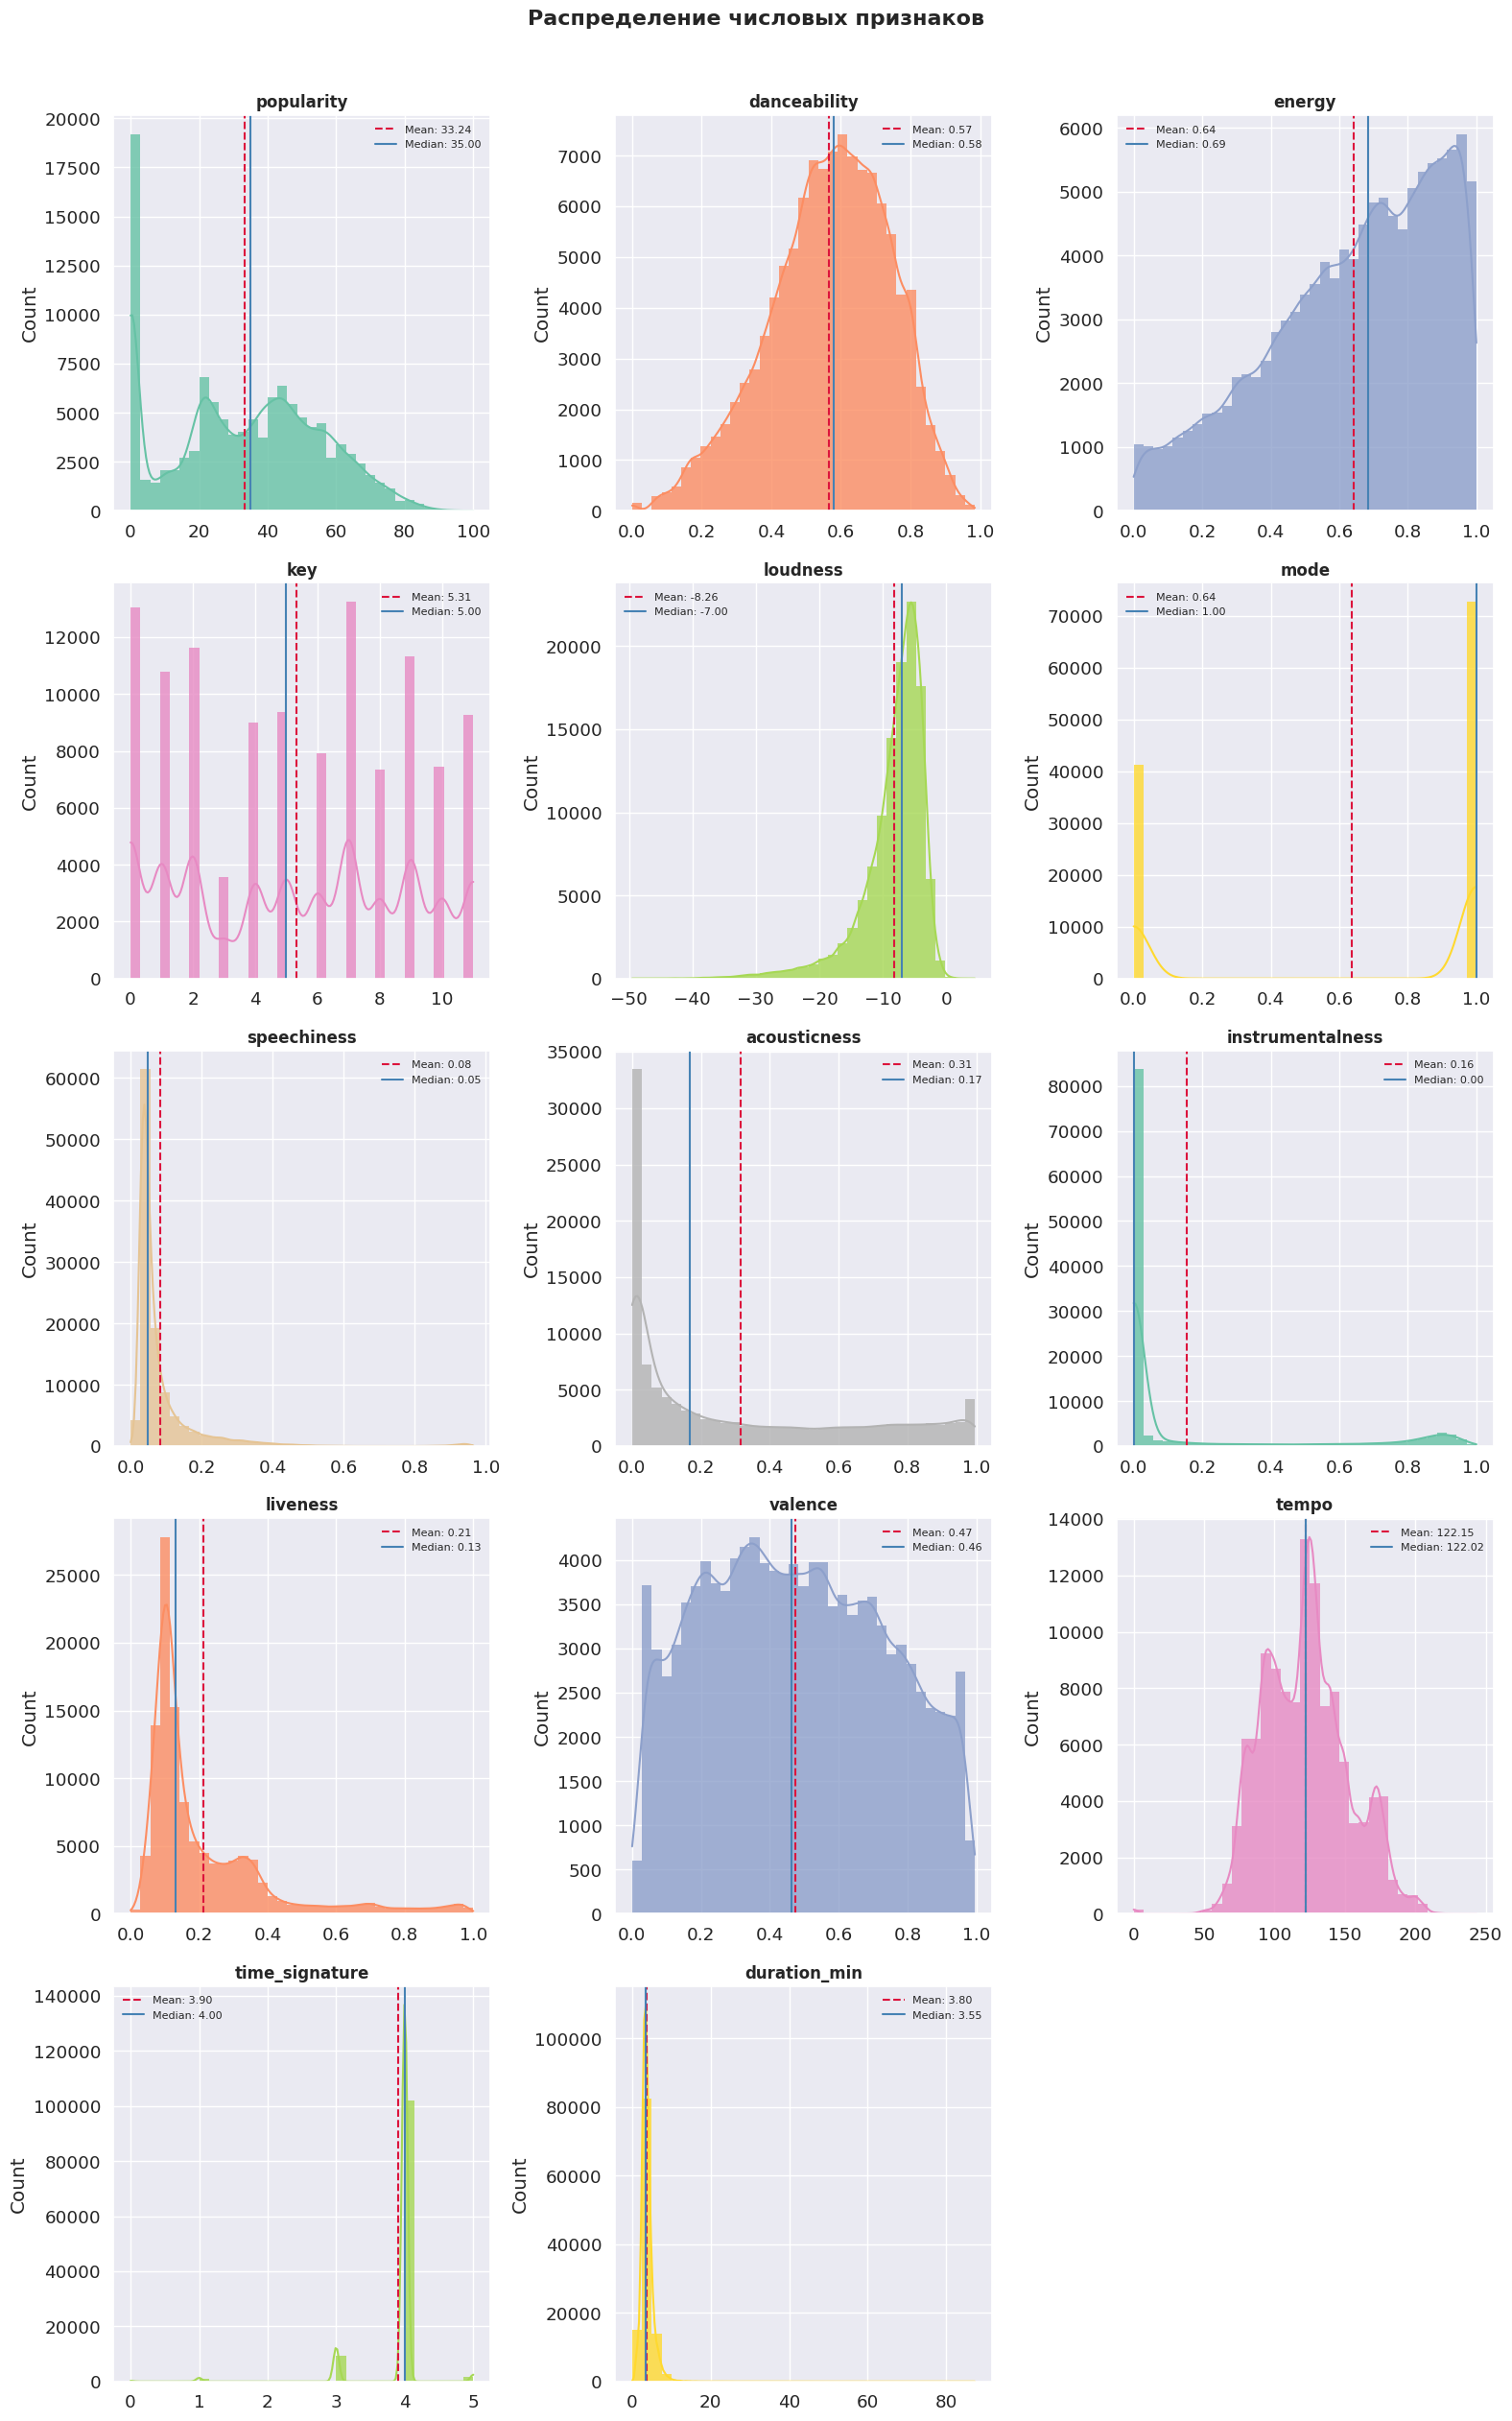

In [35]:
n_cols = 3
n_rows = (len(cols_plot) + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 5 * n_rows))
axes = axes.flatten()
COLORS = plt.cm.Set2.colors

for i, col in enumerate(cols_plot):
    ax = axes[i]
    sns.histplot(data=df, x=col, kde=True, bins=35,
                 color=COLORS[i % len(COLORS)], edgecolor='none', alpha=0.8, ax=ax)
    ax.axvline(df[col].mean(),   color='crimson',   ls='--', lw=1.5,
               label=f'Mean: {df[col].mean():.2f}')
    ax.axvline(df[col].median(), color='steelblue', ls='-',  lw=1.5,
               label=f'Median: {df[col].median():.2f}')
    ax.set_title(col, fontsize=12, fontweight='bold')
    ax.set_xlabel('')
    ax.legend(fontsize=8)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

fig.suptitle('Распределение числовых признаков', fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

### 2. Scatter plots — зависимости между признаками (seaborn)

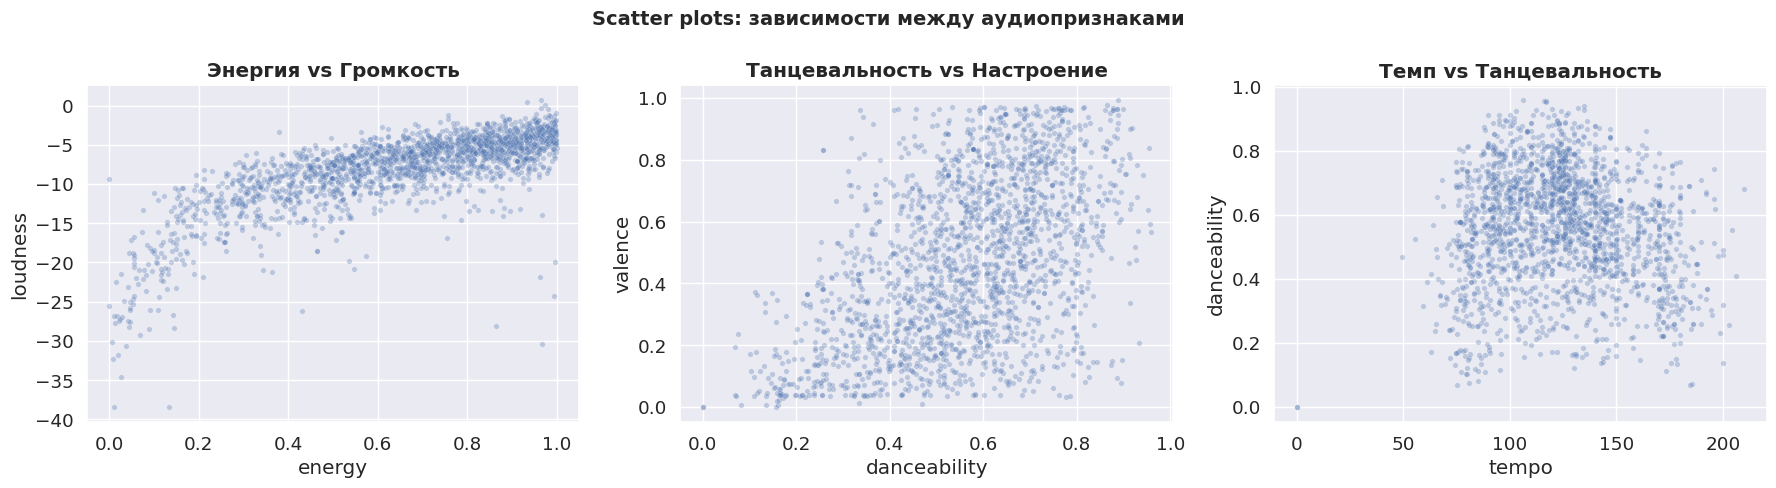

In [36]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

pairs = [
    ('energy',       'loudness',     'Энергия vs Громкость'),
    ('danceability', 'valence',      'Танцевальность vs Настроение'),
    ('tempo',        'danceability', 'Темп vs Танцевальность'),
]

for ax, (x, y, title) in zip(axes, pairs):
    sns.scatterplot(data=df.sample(2000, random_state=42), x=x, y=y,
                    alpha=0.3, s=15, ax=ax)
    ax.set_title(title, fontweight='bold')

plt.suptitle('Scatter plots: зависимости между аудиопризнаками', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

###  3. Box plots — обнаружение выбросов (seaborn)

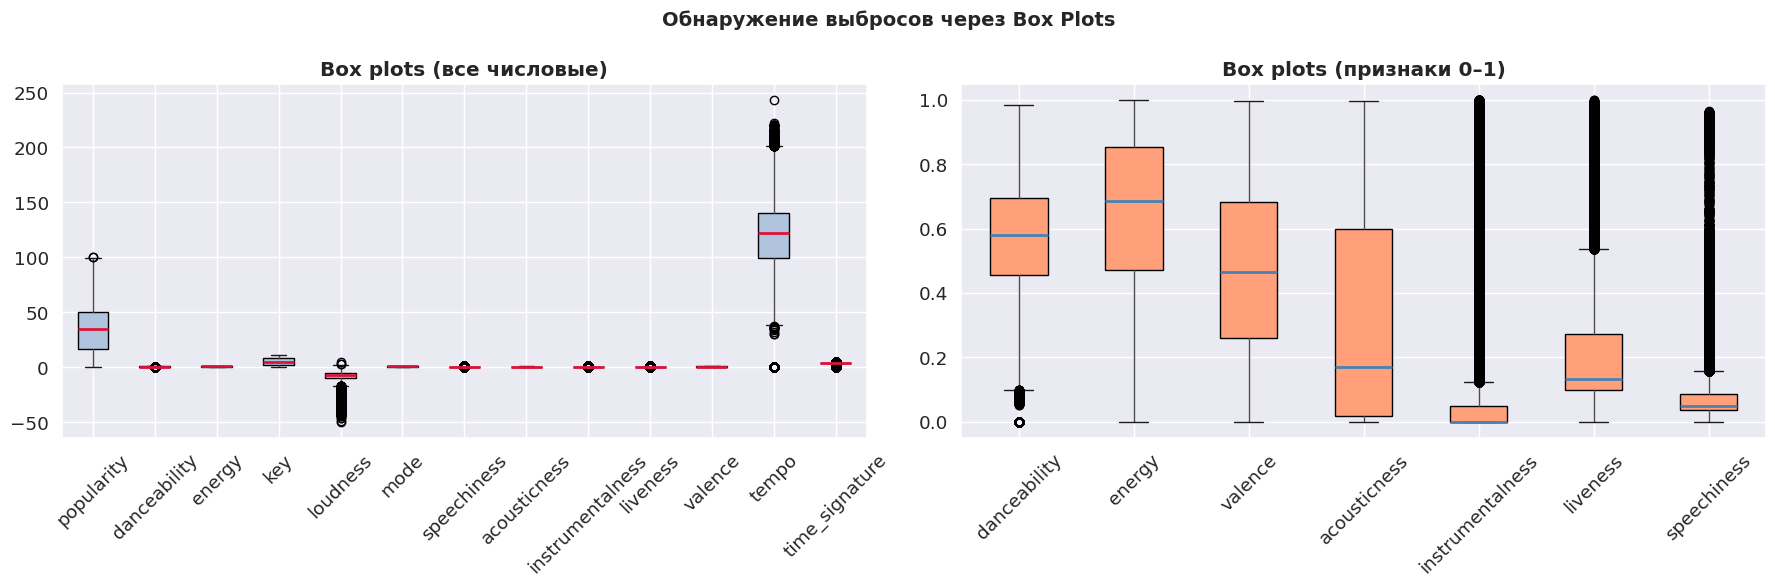

In [37]:
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Все числовые (кроме duration_min — масштаб другой)
box_cols = [c for c in cols_plot if c != 'duration_min']
df[box_cols].boxplot(ax=axes[0], patch_artist=True,
    boxprops=dict(facecolor='lightsteelblue'),
    medianprops=dict(color='crimson', lw=2))
axes[0].set_title('Box plots (все числовые)', fontweight='bold')
axes[0].tick_params(axis='x', rotation=45)

# Только признаки в диапазоне 0–1
norm_cols = [c for c in ['danceability', 'energy', 'valence', 'acousticness',
                          'instrumentalness', 'liveness', 'speechiness'] if c in df.columns]
df[norm_cols].boxplot(ax=axes[1], patch_artist=True,
    boxprops=dict(facecolor='lightsalmon'),
    medianprops=dict(color='steelblue', lw=2))
axes[1].set_title('Box plots (признаки 0–1)', fontweight='bold')
axes[1].tick_params(axis='x', rotation=45)

plt.suptitle('Обнаружение выбросов через Box Plots', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

###  4. Violin plots — плотность popularity по жанрам (seaborn)

/tmp/ipykernel_32615/3095088998.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df_top, x='track_genre', y='popularity',


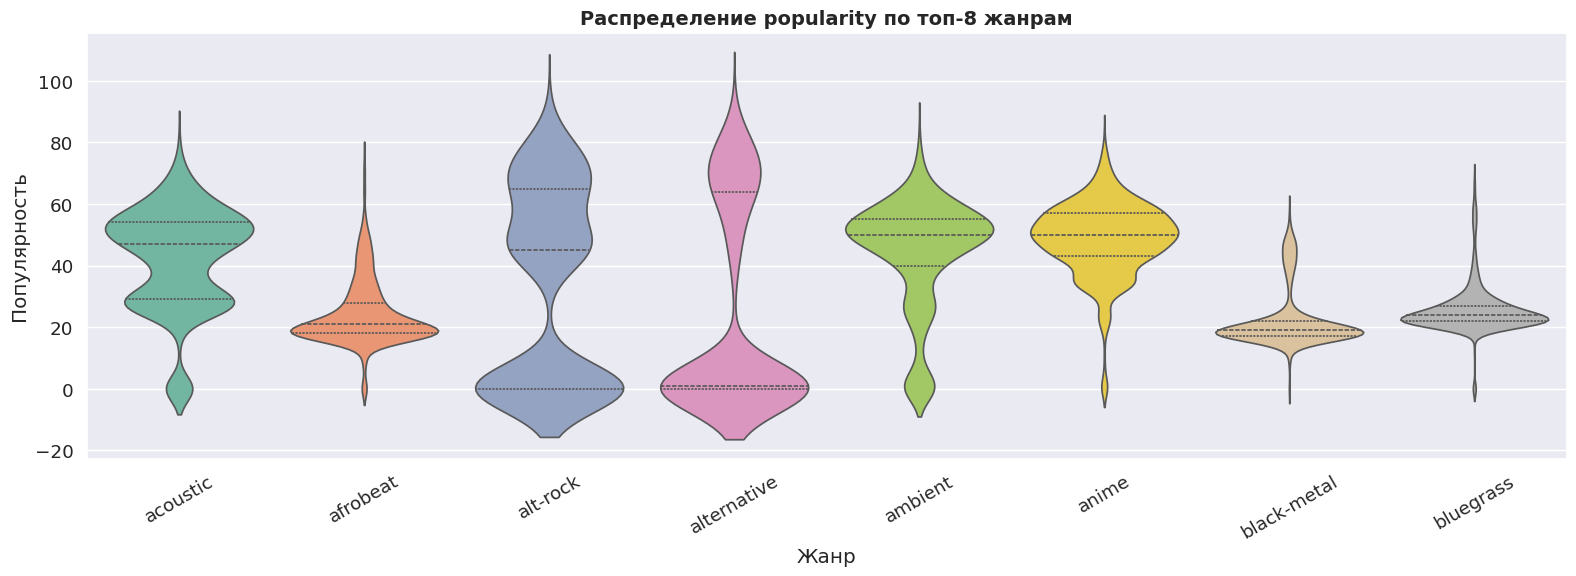

In [38]:
top_genres = df['track_genre'].value_counts().head(8).index
df_top = df[df['track_genre'].isin(top_genres)]

plt.figure(figsize=(16, 6))
sns.violinplot(data=df_top, x='track_genre', y='popularity',
               palette='Set2', inner='quartile', density_norm='width')
plt.title('Распределение popularity по топ-8 жанрам', fontsize=14, fontweight='bold')
plt.xlabel('Жанр')
plt.ylabel('Популярность')
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

###  5. Count plot — частота жанров (matplotlib)

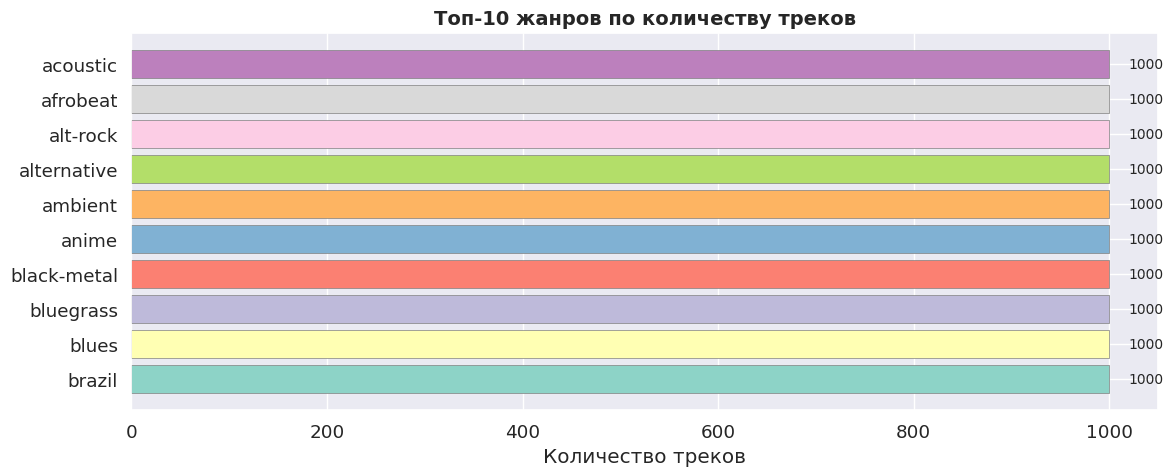

In [39]:
top10 = df['track_genre'].value_counts().head(10)

plt.figure(figsize=(12, 5))
bars = plt.barh(top10.index[::-1], top10.values[::-1],
                color=plt.cm.Set3(range(10)), edgecolor='grey', linewidth=0.5)
for bar, val in zip(bars, top10.values[::-1]):
    plt.text(bar.get_width() + 20, bar.get_y() + bar.get_height() / 2,
             str(val), va='center', fontsize=10)
plt.title('Топ-10 жанров по количеству треков', fontsize=14, fontweight='bold')
plt.xlabel('Количество треков')
plt.tight_layout()
plt.show()

### 6. Heatmap корреляций (seaborn)

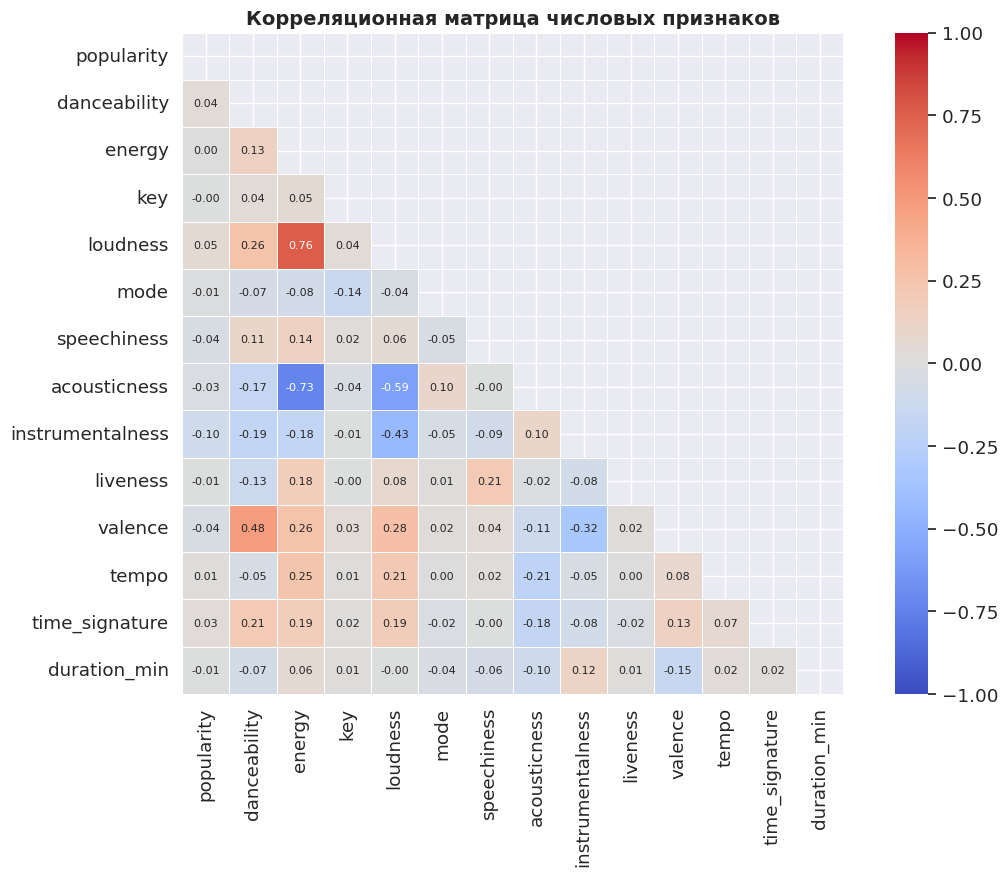

In [41]:
corr_cols = [c for c in cols_plot if c in df.columns]
corr = df[corr_cols].corr()

mask = np.triu(np.ones_like(corr, dtype=bool))

plt.figure(figsize=(12, 9))
sns.heatmap(
    corr, mask=mask, annot=True, fmt='.2f',
    cmap='coolwarm', center=0, vmin=-1, vmax=1,
    square=True, linewidths=0.5, annot_kws={'size': 8}
)
plt.title('Корреляционная матрица числовых признаков', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

**Выводы по корреляционной матрице:**

- **Сильная положительная корреляция** (`r ≈ 0.7–0.8`): `energy` и `loudness` — чем энергичнее трек, тем он громче. Физически обоснованная связь.
- **Умеренная отрицательная корреляция** (`r ≈ -0.5`): `energy` и `acousticness` — акустическая музыка, как правило, менее энергична.
- `danceability` и `valence` умеренно положительно коррелируют — «весёлые» треки чаще танцевальные.
- `instrumentalness` слабо коррелирует с остальными признаками — инструментальность не определяется стандартными аудиохарактеристиками.
- `popularity` имеет слабую корреляцию со всеми признаками — популярность трека определяется не только аудиохарактеристиками.


###  7. Интерактивный scatter plot (Plotly)

In [42]:
fig = px.scatter(
    df.sample(3000, random_state=42),
    x='energy', y='danceability',
    color='track_genre',
    size='popularity',
    size_max=12,
    hover_data=['track_name', 'artists', 'popularity', 'tempo'],
    opacity=0.6,
    title='Energy vs Danceability по жанрам (интерактивный)',
    labels={'energy': 'Энергия', 'danceability': 'Танцевальность'},
    template='plotly_white'
)
fig.update_layout(showlegend=False, height=550)
fig.show()

###  8. Pairplot ключевых признаков (seaborn)

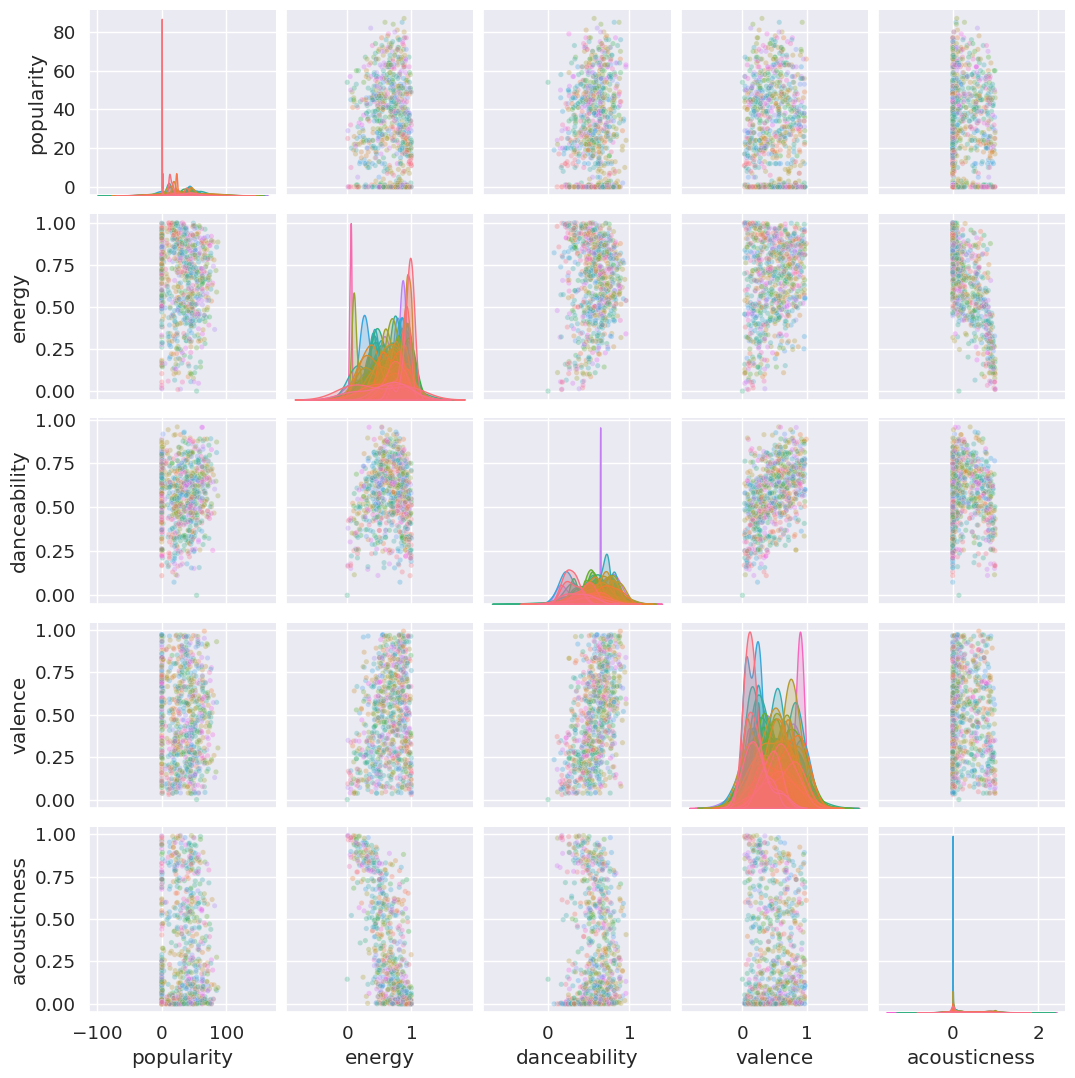

<Figure size 1200x800 with 0 Axes>

In [48]:
pair_cols = ['popularity', 'energy', 'danceability', 'valence', 'acousticness']
g = sns.pairplot(
    df[pair_cols + ['track_genre']].sample(800, random_state=42),
    hue='track_genre',
    vars=pair_cols,
    diag_kind='kde',
    plot_kws={'alpha': 0.3, 's': 15},
    height=2.2
)

g._legend.remove()

plt.tight_layout()
plt.show()

## F)  Итоговые выводы


###  Что я узнала про датасет

1. **Датасет большой и разнообразный**: тысячи треков из множества жанров с богатым набором аудиохарактеристик — идеален для задач классификации и регрессии.

2. **Пропусков критически мало**: после загрузки практически все колонки заполнены; очистка не требовала радикальных решений.

3. **Масштабы признаков сильно различаются**: `duration_ms` измеряется в миллионах, `popularity` — 0–100, а большинство аудиопризнаков — в диапазоне 0–1. Перед моделированием необходима нормализация.

4. **Energy и loudness очень тесно связаны** (r ≈ 0.8): эти признаки несут частично одинаковую информацию. При обучении модели стоит рассмотреть удаление одного из них.

5. **Popularity распределена асимметрично** (правый скос): большинство треков имеют среднюю популярность, но есть длинный правый хвост суперпопулярных треков — это следует учитывать при выборе метрики.

6. **Высокий эксцесс у popularity**: наличие «тяжёлых хвостов» говорит о выбросах — редких треках с экстремально высокой или нулевой популярностью.

7. **Instrumentalness крайне скошена**: подавляющее большинство треков не инструментальные (значение близко к 0), а инструментальные — редкость в датасете.

8. **Распределение по жанрам неравномерно**: некоторые жанры представлены значительно чаще других, что создаёт дисбаланс классов при задаче жанровой классификации.

9. **Feature Hashing полезен для `artists`**: у исполнителей сотни уникальных значений, One-Hot Encoding создал бы матрицу с тысячами колонок.

10. **Новые признаки `energy_dance` и `duration_min`** добавляют интерпретабельность: первый описывает суммарную «энергетическую танцевальность», второй удобнее для анализа длительности.


### Гипотезы и наблюдения

1. **Жанр → популярность**: pop и dance-треки, вероятно, имеют систематически более высокую популярность. Violin plot намекает на разные распределения по жанрам — стоит проверить статистически (t-тест или ANOVA).

2. **Energy + loudness → мультиколлинеарность**: для линейных моделей нужно будет убрать один из этих признаков или применить PCA, иначе коэффициенты будут нестабильны.

3. **Instrumentalness как разделитель кластеров**: треки с высокой `instrumentalness` образуют отдельный кластер в пространстве признаков. При кластеризации (K-Means, DBSCAN) этот признак должен дать чёткое разбиение.

4. **Выбросы в `duration_ms`**: очень длинные треки (30+ минут) — вероятно, подкасты или классические произведения — могут ухудшать модели. Стоит отфильтровать или обработать отдельно.

5. **Popularity слабо линейно зависит от аудиопризнаков**: корреляции с `popularity` низкие у всех признаков. Это говорит о нелинейной природе популярности — деревья решений и градиентный бустинг справятся лучше линейных моделей.


###  Что делать дальше

**Задача:** предсказать `popularity` трека по его аудиохарактеристикам и жанру.

1. **Предобработка**: нормализовать признаки (MinMaxScaler или StandardScaler), отфильтровать аномально длинные треки (> 10 мин), разделить данные train/test.

2. **Baseline**: `LinearRegression` — быстрый старт, даёт нижнюю планку качества.

3. **Основные модели**:
   - `RandomForestRegressor` — устойчив к выбросам, автоматически отбирает важные признаки
   - `GradientBoostingRegressor` / `XGBRegressor` — как правило, лучший результат на табличных данных

4. **Альтернативная задача**: жанровая классификация — многоклассовая задача, где аудиопризнаки должны хорошо разделять жанры.

5. **Отбор признаков**: проверить важность через `feature_importances_` Random Forest, убрать мультиколлинеарные пары (energy/loudness), применить `SelectKBest`.


###  Использование AI и самостоятельная работа

**Что делалось с подсказками AI:**
- Примеры синтаксиса `HashingEncoder` и `category_encoders`
- Структура subplot-сетки для множественных гистограмм
- Шаблон для Plotly scatter с `hover_data`

**Что проверялось и дописывалось самостоятельно:**
- Запуск и отладка всех ячеек, адаптация под конкретные колонки датасета
- Выбор стратегий `fillna` с обоснованием для каждого признака
- Интерпретация skewness/kurtosis на реальных данных
- Анализ корреляционной матрицы и формулировка гипотез
- Оформление структуры ноутбука и финальных выводов
